In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [11]:
df = pd.read_csv('/home/dabiyyu/projects/data-scientist/churn-prediction/data/Telco_customer_churn.csv', delimiter=";")

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (7043, 33)

Column names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [12]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783","33,964131","-118,272783",Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742","34,059281","-118,307420",Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953","34,048013","-118,293953",Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"99,65","820,5",Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709","34,062125","-118,315709",Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,"104,8","3046,05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293","34,039224","-118,266293",Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),"103,7","5036,3",Yes,1,89,5340,Competitor had better devices


In [22]:
pd.DataFrame(df.dtypes)

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,object
Longitude,object
Gender,object


In [21]:
pd.DataFrame(df.isnull().sum())

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [25]:
# See all columns clearly
for i, col in enumerate(df.columns):
    print(f"{i+1:02d}. {col} — dtype: {df[col].dtype} — nulls: {df[col].isnull().sum()}")

01. CustomerID — dtype: object — nulls: 0
02. Count — dtype: int64 — nulls: 0
03. Country — dtype: object — nulls: 0
04. State — dtype: object — nulls: 0
05. City — dtype: object — nulls: 0
06. Zip Code — dtype: int64 — nulls: 0
07. Lat Long — dtype: object — nulls: 0
08. Latitude — dtype: object — nulls: 0
09. Longitude — dtype: object — nulls: 0
10. Gender — dtype: object — nulls: 0
11. Senior Citizen — dtype: object — nulls: 0
12. Partner — dtype: object — nulls: 0
13. Dependents — dtype: object — nulls: 0
14. Tenure Months — dtype: int64 — nulls: 0
15. Phone Service — dtype: object — nulls: 0
16. Multiple Lines — dtype: object — nulls: 0
17. Internet Service — dtype: object — nulls: 0
18. Online Security — dtype: object — nulls: 0
19. Online Backup — dtype: object — nulls: 0
20. Device Protection — dtype: object — nulls: 0
21. Tech Support — dtype: object — nulls: 0
22. Streaming TV — dtype: object — nulls: 0
23. Streaming Movies — dtype: object — nulls: 0
24. Contract — dtype: obj

In [26]:
# Check all object columns — see what categories exist
obj_cols = df.select_dtypes(include='object').columns

for col in obj_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().head())


CustomerID (7043 unique):
CustomerID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
Name: count, dtype: int64

Country (1 unique):
Country
United States    7043
Name: count, dtype: int64

State (1 unique):
State
California    7043
Name: count, dtype: int64

City (1129 unique):
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Name: count, dtype: int64

Lat Long (1652 unique):
Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
Name: count, dtype: int64

Latitude (1652 unique):
Latitude
34,159534    5
33,281560    5
34,201108    5
33,798266    5
33,391181    5
Name: count, dtype: int64

Longitude (1651 unique):
Longitude
-121,994813    8
-118,300942    5
-118,463365    5
-118,431791    5
-118,699048    5
Name: count, dtype: int64

Gender (2 unique):
Gender
Male      3555
Female    3488
Name: count, 

In [29]:
# This is usually stored as object due to spaces
print("TotalCharges dtype:", df['Total Charges'].dtype)
print("\nSample values:")
print(df['Total Charges'].head(10))

# Check for problematic values
print("\nNon-numeric values:")
mask = pd.to_numeric(df['Total Charges'], errors='coerce').isnull()
print(df.loc[mask, 'Total Charges'])

TotalCharges dtype: object

Sample values:
0     108,15
1     151,65
2      820,5
3    3046,05
4     5036,3
5     528,35
6      39,65
7      20,15
8    4749,15
9       30,2
Name: Total Charges, dtype: object

Non-numeric values:
0        108,15
1        151,65
2         820,5
3       3046,05
4        5036,3
         ...   
7038     1419,4
7039     1990,5
7040     7362,9
7041     346,45
7042     6844,5
Name: Total Charges, Length: 6719, dtype: object


In [31]:
# Fix Total Charges — convert to numeric, coerce errors to NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Check how many NaNs were created
print("Nulls in Total Charges:", df['Total Charges'].isnull().sum())

# Inspect those rows
print(df[df['Total Charges'].isnull()][['Tenure Months', 'Monthly Charges', 'Total Charges']])

Nulls in Total Charges: 6719
      Tenure Months Monthly Charges  Total Charges
0                 2           53,85            NaN
1                 2            70,7            NaN
2                 8           99,65            NaN
3                28           104,8            NaN
4                49           103,7            NaN
...             ...             ...            ...
7038             72           21,15            NaN
7039             24            84,8            NaN
7040             72           103,2            NaN
7041             11            29,6            NaN
7042             66          105,65            NaN

[6719 rows x 3 columns]


In [32]:
# Drop columns not useful for modeling
cols_to_drop = [
    'Count',        # constant value
    'Country',      # constant value (all US)
    'State',        # low variance
    'Lat Long',     # redundant with Latitude/Longitude
]

df = df.drop(columns=cols_to_drop)
print("Shape after dropping:", df.shape)

Shape after dropping: (7043, 29)


In [33]:
# Group columns for easier reference later
id_cols = ['CustomerID']

geo_cols = ['City', 'Zip Code', 'Latitude', 'Longitude']

target_cols = ['Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason']

feature_cols = [col for col in df.columns 
                if col not in id_cols + geo_cols + target_cols]

print("Feature columns:")
print(feature_cols)

Feature columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


In [34]:
# Numerical columns
df.describe()

,Zip Code,Tenure Months,Total Charges,Churn Value,Churn Score,CLTV
count,7043.00,7043.00,324.00,7043.00,7043.00,7043.00
mean,93521.96,32.37,2323.94,0.27,58.70,4400.30
std,1865.79,24.56,2224.94,0.44,21.53,1183.06
min,90001.00,0.00,19.00,0.00,5.00,2003.00
25%,92102.00,9.00,450.00,0.00,40.00,3469.00
50%,93552.00,29.00,1409.50,0.00,61.00,4527.00
75%,95351.00,55.00,3818.00,1.00,75.00,5380.50
max,96161.00,72.00,8405.00,1.00,100.00,6500.00


In [35]:
# Churn distribution — our target
print("Churn Distribution:")
print(df['Churn Label'].value_counts())
print("\nChurn Rate:")
print(df['Churn Label'].value_counts(normalize=True).round(3))

Churn Distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate:
Churn Label
No    0.73
Yes   0.27
Name: proportion, dtype: float64


In [37]:
df["Total Charges"].isnull().sum()

np.int64(6719)

In [38]:
# Look at the null rows
null_tc = df[df['Total Charges'].isnull()]

print("Null Total Charges rows:", len(null_tc))
print("\nTenure distribution for null rows:")
print(null_tc['Tenure Months'].describe())
print("\nChurn Label for null rows:")
print(null_tc['Churn Label'].value_counts())
print("\nSample raw values before conversion:")

Null Total Charges rows: 6719

Tenure distribution for null rows:
count   6719.00
mean      32.31
std       24.57
min        0.00
25%        9.00
50%       29.00
75%       55.00
max       72.00
Name: Tenure Months, dtype: float64

Churn Label for null rows:
Churn Label
No     4928
Yes    1791
Name: count, dtype: int64

Sample raw values before conversion:


In [41]:
# Reload just that column from raw file to see original values
raw = pd.read_csv('/home/dabiyyu/projects/data-scientist/churn-prediction/data/Telco_customer_churn.csv', delimiter=";")
print(raw.loc[df['Total Charges'].isnull(), 'Total Charges'].value_counts().head(20))

Total Charges
         11
20,2     11
19,75     9
19,65     8
20,05     8
19,9      8
45,3      7
19,55     7
20,25     6
20,15     6
19,45     6
20,45     5
20,3      5
19,4      4
50,15     4
19,3      4
49,9      4
20,4      4
44,4      4
70,6      4
Name: count, dtype: int64


In [42]:
# Reload fresh to avoid working on already-broken column
df['Total Charges'] = (
    raw['Total Charges']
    .str.replace(',', '.')   # replace comma decimal with period
    .str.strip()             # remove any whitespace
    .pipe(pd.to_numeric, errors='coerce')  # convert to float
)

# Verify
print("Nulls remaining:", df['Total Charges'].isnull().sum())
print("\nSample values:")
print(df['Total Charges'].dropna().head(10))
print("\ndtype:", df['Total Charges'].dtype)

Nulls remaining: 11

Sample values:
0    108.15
1    151.65
2    820.50
3   3046.05
4   5036.30
5    528.35
6     39.65
7     20.15
8   4749.15
9     30.20
Name: Total Charges, dtype: float64

dtype: float64


In [43]:
# Check remaining nulls
remaining = df[df['Total Charges'].isnull()]
print("Remaining nulls:", len(remaining))
print(remaining[['Tenure Months', 'Monthly Charges', 'Total Charges']])

Remaining nulls: 11
      Tenure Months Monthly Charges  Total Charges
2234              0           52,55            NaN
2438              0           20,25            NaN
2568              0           80,85            NaN
2667              0           25,75            NaN
2856              0           56,05            NaN
4331              0           19,85            NaN
4687              0           25,35            NaN
5104              0              20            NaN
5719              0            19,7            NaN
6772              0           73,35            NaN
6840              0            61,9            NaN


In [44]:
# For customers with 0 tenure, Total Charges should be 0
df['Total Charges'] = df['Total Charges'].fillna(0)

# Final check
print("Nulls after fix:", df['Total Charges'].isnull().sum())
print("dtype:", df['Total Charges'].dtype)

Nulls after fix: 0
dtype: float64


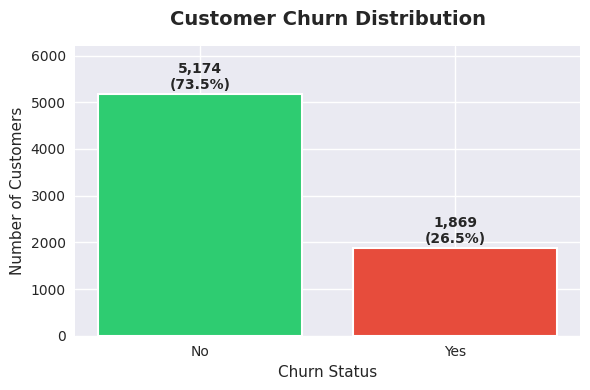


Business Insight: 26.5% of customers churned
That's 1,869 customers lost out of 7,043 total


In [45]:
churn_counts = df['Churn Label'].value_counts()
churn_rate = df['Churn Label'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(churn_counts.index, churn_counts.values, 
              color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)

for bar, val, pct in zip(bars, churn_counts.values, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({pct:.1%})', ha='center', va='bottom', fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Churn Status')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, churn_counts.max() * 1.2)
sns.despine()

plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBusiness Insight: {churn_rate['Yes']:.1%} of customers churned")
print(f"That's {churn_counts['Yes']:,} customers lost out of {len(df):,} total")

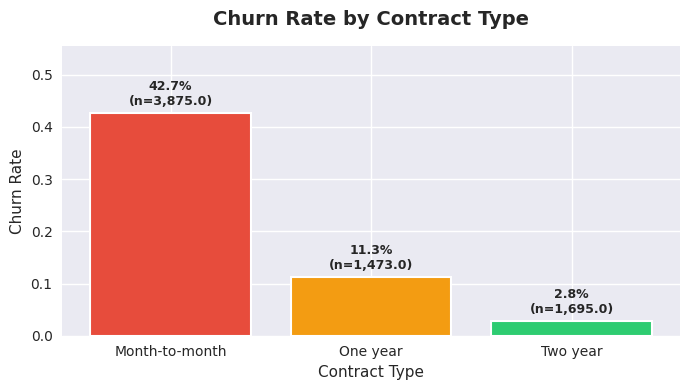


Business Insight:
  Month-to-month: 42.7% churn rate (1655.0 customers lost)
  One year: 11.3% churn rate (166.0 customers lost)
  Two year: 2.8% churn rate (48.0 customers lost)


In [46]:
contract_churn = df.groupby('Contract')['Churn Value'].agg(['mean', 'count'])
contract_churn.columns = ['Churn Rate', 'Customer Count']
contract_churn['Churned'] = (contract_churn['Churn Rate'] * contract_churn['Customer Count']).astype(int)
contract_churn = contract_churn.sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contract_churn.index, contract_churn['Churn Rate'],
              color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=1.5)

for bar, (idx, row) in zip(bars, contract_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row['Churn Rate']:.1%}\n(n={row['Customer Count']:,})",
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate')
ax.set_ylim(0, contract_churn['Churn Rate'].max() * 1.3)
sns.despine()

plt.tight_layout()
plt.savefig('../reports/figures/02_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBusiness Insight:")
for idx, row in contract_churn.iterrows():
    print(f"  {idx}: {row['Churn Rate']:.1%} churn rate ({row['Churned']} customers lost)")

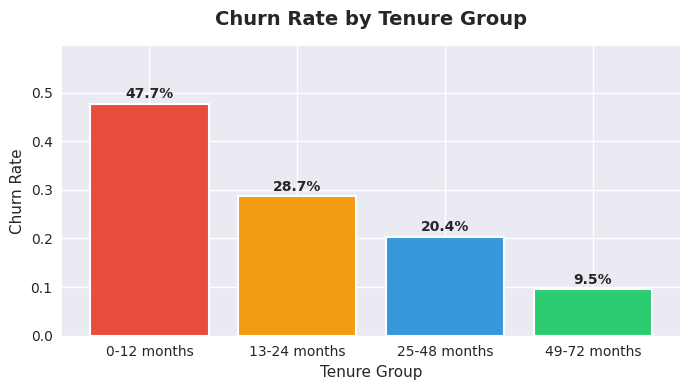


Business Insight:
  0-12 months: 47.7% churn rate
  13-24 months: 28.7% churn rate
  25-48 months: 20.4% churn rate
  49-72 months: 9.5% churn rate


In [47]:
# Bin tenure into business-meaningful groups
df['Tenure Group'] = pd.cut(df['Tenure Months'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months', 
                                     '25-48 months', '49-72 months'])

tenure_churn = df.groupby('Tenure Group', observed=True)['Churn Value'].agg(['mean', 'count'])
tenure_churn.columns = ['Churn Rate', 'Customer Count']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tenure_churn.index, tenure_churn['Churn Rate'],
              color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
              edgecolor='white', linewidth=1.5)

for bar, (idx, row) in zip(bars, tenure_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{row['Churn Rate']:.1%}", ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

ax.set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate')
ax.set_ylim(0, tenure_churn['Churn Rate'].max() * 1.25)
sns.despine()

plt.tight_layout()
plt.savefig('../reports/figures/03_churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBusiness Insight:")
for idx, row in tenure_churn.iterrows():
    print(f"  {idx}: {row['Churn Rate']:.1%} churn rate")

In [50]:
# Check current state
print("Monthly Charges dtype:", df['Monthly Charges'].dtype)
print("Sample values:", df['Monthly Charges'].head())

Monthly Charges dtype: object
Sample values: 0    53,85
1     70,7
2    99,65
3    104,8
4    103,7
Name: Monthly Charges, dtype: object


In [51]:
# Fix comma decimal separator
df['Monthly Charges'] = (
    df['Monthly Charges']
    .astype(str)
    .str.replace(',', '.')
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
)

print("After fix:")
print("dtype:", df['Monthly Charges'].dtype)
print("Nulls:", df['Monthly Charges'].isnull().sum())
print("Sample:", df['Monthly Charges'].head())

After fix:
dtype: float64
Nulls: 0
Sample: 0    53.85
1    70.70
2    99.65
3   104.80
4   103.70
Name: Monthly Charges, dtype: float64


In [52]:
# Check which object columns might be numeric with comma decimals
obj_cols = df.select_dtypes(include='object').columns

for col in obj_cols:
    # Try converting after replacing commas
    converted = (df[col].astype(str)
                 .str.replace(',', '.')
                 .str.strip()
                 .pipe(pd.to_numeric, errors='coerce'))
    
    # If more than 80% converted successfully, it's a numeric column
    success_rate = converted.notna().sum() / len(df)
    if success_rate > 0.8:
        print(f"Fixing: {col} (success rate: {success_rate:.1%})")
        df[col] = converted

Fixing: Latitude (success rate: 100.0%)
Fixing: Longitude (success rate: 100.0%)


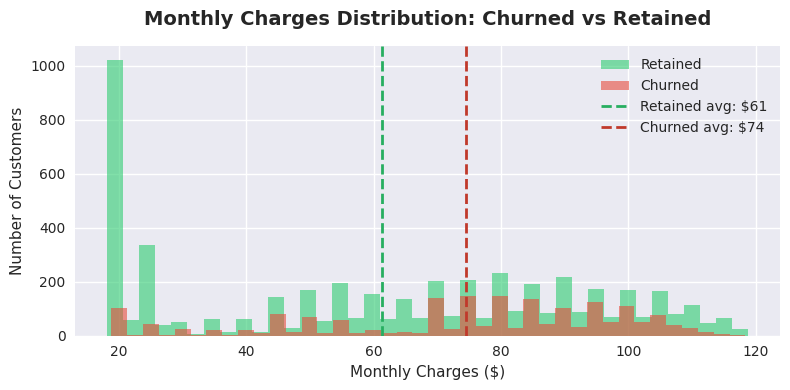


Business Insight:
  Retained customers avg monthly charge: $61.27
  Churned customers avg monthly charge:  $74.44


In [53]:
fig, ax = plt.subplots(figsize=(8, 4))

df[df['Churn Label'] == 'No']['Monthly Charges'].hist(
    bins=40, alpha=0.6, color='#2ecc71', label='Retained', ax=ax)
df[df['Churn Label'] == 'Yes']['Monthly Charges'].hist(
    bins=40, alpha=0.6, color='#e74c3c', label='Churned', ax=ax)

ax.axvline(df[df['Churn Label'] == 'No']['Monthly Charges'].mean(),
           color='#27ae60', linestyle='--', linewidth=2,
           label=f"Retained avg: ${df[df['Churn Label']=='No']['Monthly Charges'].mean():.0f}")
ax.axvline(df[df['Churn Label'] == 'Yes']['Monthly Charges'].mean(),
           color='#c0392b', linestyle='--', linewidth=2,
           label=f"Churned avg: ${df[df['Churn Label']=='Yes']['Monthly Charges'].mean():.0f}")

ax.set_title('Monthly Charges Distribution: Churned vs Retained',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend()
sns.despine()

plt.tight_layout()
plt.savefig('../reports/figures/04_monthly_charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBusiness Insight:")
print(f"  Retained customers avg monthly charge: ${df[df['Churn Label']=='No']['Monthly Charges'].mean():.2f}")
print(f"  Churned customers avg monthly charge:  ${df[df['Churn Label']=='Yes']['Monthly Charges'].mean():.2f}")

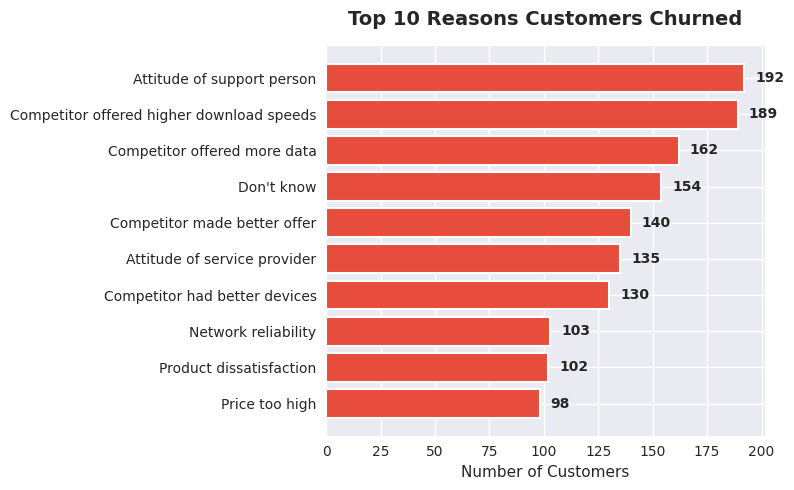


Top 5 churn reasons:
Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Name: count, dtype: int64


In [49]:
churn_reasons = (df[df['Churn Reason'].notna()]['Churn Reason']
                 .value_counts()
                 .head(10))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(churn_reasons.index[::-1], churn_reasons.values[::-1],
               color='#e74c3c', edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, churn_reasons.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

ax.set_title('Top 10 Reasons Customers Churned', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Customers')
sns.despine()

plt.tight_layout()
plt.savefig('../reports/figures/05_churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 churn reasons:")
print(churn_reasons.head())

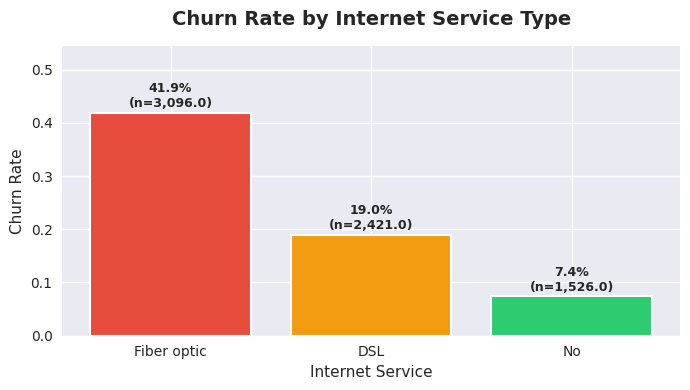


Business Insight:
  Fiber optic: 41.9% churn rate
  DSL: 19.0% churn rate
  No: 7.4% churn rate


In [54]:
internet_churn = (df.groupby('Internet Service')['Churn Value']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'Churn Rate', 'count': 'Customer Count'})
                  .sort_values('Churn Rate', ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(internet_churn.index, internet_churn['Churn Rate'],
              color=['#e74c3c', '#f39c12', '#2ecc71'],
              edgecolor='white', linewidth=1.5)

for bar, (idx, row) in zip(bars, internet_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{row['Churn Rate']:.1%}\n(n={row['Customer Count']:,})",
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Internet Service')
ax.set_ylabel('Churn Rate')
ax.set_ylim(0, internet_churn['Churn Rate'].max() * 1.3)
sns.despine()

plt.tight_layout()
plt.savefig('../reports/figures/06_churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBusiness Insight:")
for idx, row in internet_churn.iterrows():
    print(f"  {idx}: {row['Churn Rate']:.1%} churn rate")

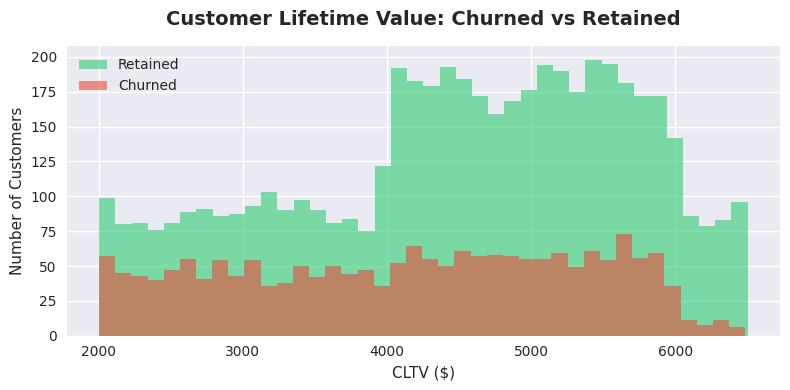

Retained customers avg CLTV: $4,491
Churned customers avg CLTV:  $4,149
Total CLTV lost to churn:    $7,755,256


In [55]:
fig, ax = plt.subplots(figsize=(8, 4))

df[df['Churn Label'] == 'No']['CLTV'].hist(
    bins=40, alpha=0.6, color='#2ecc71', label='Retained', ax=ax)
df[df['Churn Label'] == 'Yes']['CLTV'].hist(
    bins=40, alpha=0.6, color='#e74c3c', label='Churned', ax=ax)

ax.set_title('Customer Lifetime Value: Churned vs Retained',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('CLTV ($)')
ax.set_ylabel('Number of Customers')
ax.legend()
sns.despine()

plt.tight_layout()
plt.savefig('../reports/figures/07_cltv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

retained_cltv = df[df['Churn Label'] == 'No']['CLTV'].mean()
churned_cltv = df[df['Churn Label'] == 'Yes']['CLTV'].mean()
total_cltv_lost = df[df['Churn Label'] == 'Yes']['CLTV'].sum()

print(f"Retained customers avg CLTV: ${retained_cltv:,.0f}")
print(f"Churned customers avg CLTV:  ${churned_cltv:,.0f}")
print(f"Total CLTV lost to churn:    ${total_cltv_lost:,.0f}")